In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from PIL import Image
import numpy as np
import torch
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision.transforms as T
from sklearn.metrics import roc_auc_score, confusion_matrix
from tqdm import tqdm

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


In [ ]:
# Define paths
train_image_dirs = [
    "DRIVE Dataset/DRIVE/training/images", 
    "CHASE DB/CHASE DB/Image", 
    "HRF_data/images",
    "Five Fundus/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Original/Original"
]

train_label_dirs = [
    "extracted_files/DRIVE/training/1st_manual", 
    "CHASE DB/CHASE DB/Lable",
    "HRF_data/manual1",
    "Five Fundus/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Ground truth"
]


# Supported image formats
image_extensions = ('*.tif', '*.tiff', '*.png', '*.jpg', '*.jpeg', '*.gif', '*.JPG')

# Utility to get all image paths from a folder
def get_all_images(folder):
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(glob(os.path.join(folder, ext)))
    return sorted(image_paths)

# Step 1: Count and load
all_train_images = []
all_train_labels = []

# print("=== Training Data Count Per Folder ===\n")
for img_dir, lbl_dir in zip(train_image_dirs, train_label_dirs):
    imgs = get_all_images(img_dir)
    lbls = get_all_images(lbl_dir)
    # Add to combined list
    all_train_images.extend(imgs)
    all_train_labels.extend(lbls)

# Step 2: Load as paired tuples (assuming matching order)
train_image_label_pairs = list(zip(all_train_images, all_train_labels))

test_image_dirs = ["RETA_data/images/train/img"]
test_lable_dirs = ["RETA_data/images/train/vessel"]

test_images = []
test_labels = []

# print("=== Training Data Count Per Folder ===\n")
for img_dir, lbl_dir in zip(test_image_dirs, test_lable_dirs):
    imgs = get_all_images(img_dir)
    lbls = get_all_images(lbl_dir)
    # Add to combined list
    test_images.extend(imgs)
    test_labels.extend(lbls)

test_image_label_pairs = list(zip(test_images, test_labels))

print(f"Total training image-label pairs: {len(train_image_label_pairs)}")
print(f"Total training images: {len(all_train_images)}")
print(f"Total training labels: {len(all_train_labels)}")
print(f"Total test image-label pairs: {len(test_image_label_pairs)}")
print(f"Total test images: {len(test_images)}")
print(f"Total test labels: {len(test_labels)}") 

Total training image-label pairs: 693
Total training images: 693
Total training labels: 693
Total test image-label pairs: 54
Total test images: 54
Total test labels: 54


In [4]:
# Resize target
RESIZE_SHAPE = (512, 512)

# Containers
image_array_list = []
mask_array_list = []

# Load, normalize, and resize
for img_path, mask_path in train_image_label_pairs:
    img = Image.open(img_path).convert("RGB").resize(RESIZE_SHAPE)
    mask = Image.open(mask_path).convert("L").resize(RESIZE_SHAPE)

    # Normalize image: RGB to float32 [0, 1]
    img_np = np.array(img).astype(np.float32) / 255.0

    # Normalize mask: grayscale to float32 [0, 1]
    mask_np = np.array(mask).astype(np.float32) / 255.0

    image_array_list.append(img_np)
    mask_array_list.append(mask_np)

# Convert to numpy arrays
train_images = np.stack(image_array_list)  # shape: (N, H, W, 3)
train_masks = np.stack(mask_array_list)    # shape: (N, H, W)

# Containers
test_image_array_list = []
test_mask_array_list = []

# Load, normalize, and resize
for img_path, mask_path in test_image_label_pairs:
    img = Image.open(img_path).convert("RGB").resize(RESIZE_SHAPE)
    mask = Image.open(mask_path).convert("L").resize(RESIZE_SHAPE)

    # Normalize image: RGB to float32 [0, 1]
    img_np = np.array(img).astype(np.float32) / 255.0

    # Normalize mask: grayscale to float32 [0, 1]
    mask_np = np.array(mask).astype(np.float32) / 255.0

    test_image_array_list.append(img_np)
    test_mask_array_list.append(mask_np)

# Convert to numpy arrays
test_images = np.stack(test_image_array_list)  # shape: (N, H, W, 3)
test_masks = np.stack(test_mask_array_list)    # shape: (N, H, W)


# Print final shapes
print(f"Training images loaded: {train_images.shape}")
print(f"Training masks loaded: {train_masks.shape}")
print(f"Test images loaded: {test_images.shape}")
print(f"Test masks loaded: {test_masks.shape}")

Training images loaded: (693, 512, 512, 3)
Training masks loaded: (693, 512, 512)
Test images loaded: (54, 512, 512, 3)
Test masks loaded: (54, 512, 512)


In [5]:
def create_patches(images, masks, patch_size=128, stride=64):
    img_patches = []
    mask_patches = []

    img_h, img_w = images.shape[1], images.shape[2]

    for i in range(images.shape[0]):
        for y in range(0, img_h - patch_size + 1, stride):
            for x in range(0, img_w - patch_size + 1, stride):
                img_patch = images[i, y:y+patch_size, x:x+patch_size, ...]
                mask_patch = masks[i, y:y+patch_size, x:x+patch_size, ...]

                if np.sum(mask_patch) > 0:
                    img_patches.append(img_patch)
                    mask_patches.append(mask_patch)

    return np.array(img_patches), np.array(mask_patches)

In [ ]:
# Expand dimensions for grayscale masks if needed
if len(train_masks.shape) == 3:
    train_masks = np.expand_dims(train_masks, -1)

X_train, X_val, y_train, y_val = train_test_split(train_images, train_masks, test_size=0.1, random_state=42)

train_img_patches, train_mask_patches = create_patches(X_train, y_train)
val_img_patches, val_mask_patches = create_patches(X_val, y_val)

print(f"Training image patches: {train_img_patches.shape}")
print(f"Training mask patches: {train_mask_patches.shape}")
print(f"Validation image patches: {val_img_patches.shape}")
print(f"Validation mask patches: {val_mask_patches.shape}")

In [ ]:
class Augmentations:
    def __init__(self):
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ColorJitter(brightness=0.1, contrast=0.1, p=1.0),
        ])

    def __call__(self, image, mask):
        # Convert torch tensors to numpy for Albumentations
        image = image.permute(1, 2, 0).cpu().numpy()  # CxHxW -> HxWxC
        mask = mask.squeeze().cpu().numpy()  # Assume single-channel mask

        augmented = self.transform(image=image, mask=mask)

        # Convert back to torch tensors
        image = torch.from_numpy(augmented['image']).permute(2, 0, 1)  # HxWxC -> CxHxW
        mask = torch.from_numpy(augmented['mask']).unsqueeze(0)  # Add channel dim

        return image, mask

In [ ]:
class PatchDataset(Dataset):
    def __init__(self, images, masks, augment=False):
        self.images = torch.tensor(images).permute(0, 3, 1, 2).float()  # NHWC → NCHW
        self.masks = torch.tensor(masks).permute(0, 3, 1, 2).float()
        self.augment = augment
        self.aug = Augmentations()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, mask = self.images[idx], self.masks[idx]
        if self.augment:
            img, mask = self.aug(img, mask)
        return img, mask

In [ ]:
def dice_coeff(y_true, y_pred, smooth=1e-6):
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)
    intersection = (y_true * y_pred).sum()
    return (2. * intersection + smooth) / (y_true.sum() + y_pred.sum() + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = F.binary_cross_entropy(y_pred, y_true)
    return bce + dice_loss(y_true, y_pred)


In [ ]:
BATCH_SIZE = 16
train_ds = PatchDataset(train_img_patches, train_mask_patches, augment=True)
val_ds = PatchDataset(val_img_patches, val_mask_patches, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
def train_one_epoch(model, train_loader, val_loader, optimizer, EPOCHS = 10, device= device):

    best_val_loss = float('inf')
    train_losses = []
    train_dice_scores = []
    val_losses = []
    val_dice_scores = []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        train_dice = 0.0
        for images, masks in tqdm(train_loader):
            images, masks = images.to(device), masks.to(device)
            outputs = torch.sigmoid(model(images))
            loss = bce_dice_loss(masks, outputs)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_dice += dice_coeff(masks, outputs).item()

        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader):
                images, masks = images.to(device), masks.to(device)
                outputs = torch.sigmoid(model(images))
                loss = bce_dice_loss(masks, outputs)
                val_loss += loss.item()
                val_dice += dice_coeff(masks, outputs).item()

        avg_train = train_loss / len(train_loader)
        avg_train_dice = train_dice/ len(train_loader)
        avg_val = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)

        # Store metrics
        train_losses.append(avg_train)
        train_dice_scores.append(avg_train_dice)
        val_losses.append(avg_val)
        val_dice_scores.append(avg_val_dice)

        # print(f"Epoch [{epoch+1}/{EPOCHS}] - "
        #     f"Train Loss: {avg_train:.4f} - Train Dice: {train_dice_scores:.4f} - Val Loss: {avg_val:.4f} - Val Dice: {avg_val_dice:.4f}")
        print(f"Epoch [{epoch+1}/{EPOCHS}] - "
            f"Train Loss: {avg_train:.4f} - Train Dice: {avg_train_dice:.4f} - "
            f"Val Loss: {avg_val:.4f} - Val Dice: {avg_val_dice:.4f}")

        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), "unetpp_drive_best.pth")
    return train_losses, train_dice_scores, val_losses, val_dice_scores

# Train the model 
# train_losses, train_dice_scores, val_losses, val_dice_scores = train_one_epoch(model, train_loader, val_loader, optimizer, EPOCHS=10, device=device)

In [ ]:
def reconstruct_from_patches(patches, original_img_shape, patch_size=128, stride=64):
    img_h, img_w = original_img_shape
    recon_image = np.zeros((img_h, img_w, 1), dtype=np.float32)
    count_map = np.zeros((img_h, img_w, 1), dtype=np.float32)

    patch_idx = 0
    for y in range(0, img_h - patch_size + 1, stride):
        for x in range(0, img_w - patch_size + 1, stride):
            if patch_idx < len(patches):
                recon_image[y:y+patch_size, x:x+patch_size] += patches[patch_idx]
                count_map[y:y+patch_size, x:x+patch_size] += 1
                patch_idx += 1

    count_map[count_map == 0] = 1
    return recon_image / count_map

In [ ]:

def evaluate_model_pytorch(model, images, masks, patch_size=128, stride=64, device="cuda"):
    model.eval()
    metrics = {
        "dice": [],
        "iou": [],
        "accuracy": [],
        "sensitivity": [],
        "specificity": [],
        "auc": []
    }

    with torch.no_grad():
        for i in tqdm(range(len(images)), desc="Evaluating"):
            img = images[i]
            true_mask = masks[i]

            img_h, img_w = img.shape[:2]
            patches = []

            # Extract patches
            for y in range(0, img_h - patch_size + 1, stride):
                for x in range(0, img_w - patch_size + 1, stride):
                    patch = img[y:y+patch_size, x:x+patch_size, :]
                    patch_tensor = torch.tensor(patch).permute(2, 0, 1).unsqueeze(0).float().to(device)
                    out = torch.sigmoid(model(patch_tensor)).cpu().numpy()
                    patches.append(out[0].transpose(1, 2, 0))

            if len(patches) == 0:
                print(f"No patches for image {i}, skipping.")
                continue

            # Reconstruct predicted mask
            recon_mask = reconstruct_from_patches(np.array(patches), (img_h, img_w), stride=stride)
            pred_mask_bin = (recon_mask > 0.5).astype(np.uint8)

            # Flatten for metrics
            true_flat = true_mask.flatten().astype(np.uint8)
            pred_flat = recon_mask.flatten()
            pred_bin_flat = pred_mask_bin.flatten()

            if len(np.unique(true_flat)) < 2:
                print(f"Image {i} ground truth lacks both classes. Skipping.")
                continue

            tn, fp, fn, tp = confusion_matrix(true_flat, pred_bin_flat, labels=[0, 1]).ravel()

            # Metrics
            dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
            iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0
            acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            auc = roc_auc_score(true_flat, pred_flat)

            metrics["dice"].append(dice)
            metrics["iou"].append(iou)
            metrics["sensitivity"].append(sens)
            metrics["specificity"].append(spec)
            metrics["accuracy"].append(acc)
            metrics["auc"].append(auc)

    return {k: np.mean(v) for k, v in metrics.items()}


In [ ]:
def plot_validation_predictions(model, images_to_plot, true_masks, num_samples=3, patch_size=128, stride=64):
    """
    Display original images, ground truth masks, and predicted masks side by side.
    Args:
        model: Trained PyTorch model.
        images_to_plot: List or array of full validation images.
        true_masks: Corresponding ground truth masks.
        num_samples: Number of samples to visualize.
    """
    model.eval()
    num_samples = min(num_samples, len(images_to_plot))

    with torch.no_grad():
        for i in range(num_samples):
            img = images_to_plot[i]
            true_mask = true_masks[i]

            img_h, img_w = img.shape[:2]
            patch_preds = []

            for y in range(0, img_h - patch_size + 1, stride):
                for x in range(0, img_w - patch_size + 1, stride):
                    patch = img[y:y+patch_size, x:x+patch_size, :]
                    patch_tensor = torch.tensor(patch).permute(2, 0, 1).unsqueeze(0).float().to(device)
                    pred_patch = torch.sigmoid(model(patch_tensor)).cpu().numpy()
                    patch_preds.append(pred_patch[0].transpose(1, 2, 0))  # (1, H, W) → (H, W, 1)

            if len(patch_preds) == 0:
                print(f"Warning: No patches generated for image {i}, skipping.")
                continue

            pred_mask = reconstruct_from_patches(np.array(patch_preds), (img_h, img_w), stride=stride)
            pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

            # Visualization
            plt.figure(figsize=(6, 2))

            # Plot 1: Original Image
            plt.subplot(1, 3, 1)
            plt.title(f"Image #{i+1}")
            plt.imshow(img)
            plt.axis('off')

            # Plot 2: Ground Truth Mask
            plt.subplot(1, 3, 2)
            plt.title("Ground Truth Mask")
            plt.imshow(true_mask.squeeze(), cmap='gray')
            plt.axis('off')

            # Plot 3: Predicted Mask
            plt.subplot(1, 3, 3)
            plt.title("Predicted Mask by Model")
            plt.imshow(pred_mask_bin.squeeze(), cmap='gray')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

### Model-1

In [ ]:
# Define the model
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",        # Choose any backbone available in torchvision
    encoder_weights="imagenet",     # Use pretrained ImageNet weights
    in_channels=3,
    classes=1,                      # For binary segmentation 
    activation=None                 # We'll use BCEWithLogitsLoss (which expects raw logits)
)
model = model.to(device)

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.1
)

100%|██████████| 209/209 [00:05<00:00, 40.81it/s]


Epoch [1/5] - Train Loss: 0.4926 - Train Dice: 0.6537 - Val Loss: 0.3001 - Val Dice: 0.7893


100%|██████████| 209/209 [00:05<00:00, 40.22it/s]


Epoch [2/5] - Train Loss: 0.3249 - Train Dice: 0.7808 - Val Loss: 0.2787 - Val Dice: 0.8080


100%|██████████| 209/209 [00:05<00:00, 40.10it/s]


...

Epoch [5/5] - Train Loss: 0.2713 - Train Dice: 0.8175 - Val Loss: 0.2567 - Val Dice: 0.8235

--- Starting Evaluation on Validation Set ---


Evaluating:  76%|███████▌  | 53/70 [00:33<00:09,  1.73it/s]

Image 52 ground truth lacks both classes. Skipping.


Evaluating: 100%|██████████| 70/70 [00:43<00:00,  1.62it/s]



--- Final Validation Metrics (averaged) ---
Dice: 0.7031
Iou: 0.5499
Accuracy: 0.9668
Sensitivity: 0.9580
Specificity: 0.9668
Auc: 0.9931

--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


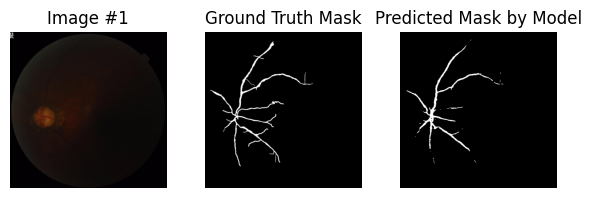

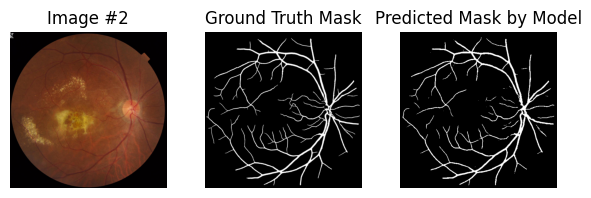

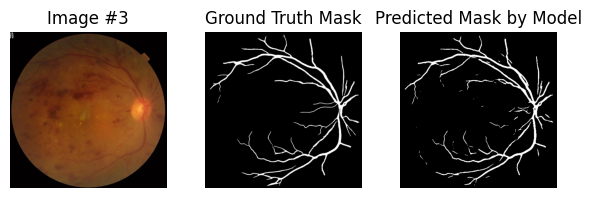

In [ ]:
train_losses, train_dice_scores, val_losses, val_dice_scores = train_one_epoch(model, train_loader, val_loader, optimizer, EPOCHS=20, device=device)

print("\n--- Starting Evaluation on Validation Set ---")
val_metrics = evaluate_model_pytorch(model, X_val, y_val)

print("\n--- Final Validation Metrics (averaged) ---")
for k, v in val_metrics.items():
    print(f"{k.capitalize()}: {v:.4f}")

print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model, X_val, y_val, num_samples=3)

Evaluating: 100%|██████████| 54/54 [00:32<00:00,  1.65it/s]



--- Final Metrics on the Test Set (averaged) ---
Dice: 0.6570
Iou: 0.4904
Accuracy: 0.9615
Sensitivity: 0.9281
Specificity: 0.9627
Auc: 0.9884

--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


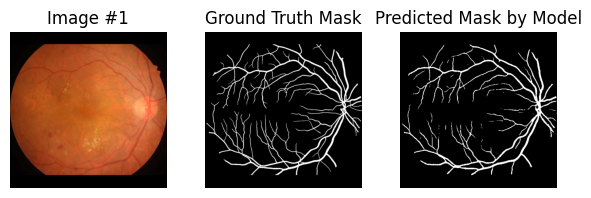

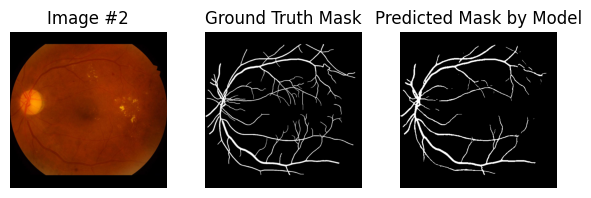

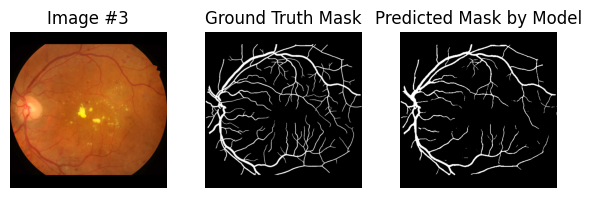

In [ ]:
# Evaluate
test_metrics = evaluate_model_pytorch(model, test_images, test_masks)

# Display results
print("\n--- Final Metrics on the Test Set (averaged) ---")
for metric, value in test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model, test_images, test_masks, num_samples=3)

### Model-2

In [ ]:
# Define the model
model1 = smp.Unet(
    encoder_name="efficientnet-b4",        # Choose any backbone available in torchvision
    encoder_weights="imagenet",     # Use pretrained ImageNet weights
    in_channels=3,                  # Number of input image channels (e.g., RGB)
    classes=1,                      # For binary segmentation
    activation=None                 # We'll use BCEWithLogitsLoss (expects raw logits)
)
model1 = model1.to(device)

In [ ]:
optimizer1 = optim.AdamW(model1.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode='min', patience=5, factor=0.1
)

100%|██████████| 209/209 [00:04<00:00, 41.99it/s]


Epoch [1/5] - Train Loss: 0.6326 - Train Dice: 0.5772 - Val Loss: 0.3259 - Val Dice: 0.7677


100%|██████████| 209/209 [00:05<00:00, 40.95it/s]


Epoch [2/5] - Train Loss: 0.3455 - Train Dice: 0.7656 - Val Loss: 0.2893 - Val Dice: 0.7968


100%|██████████| 209/209 [00:04<00:00, 47.31it/s]


...

Epoch [5/5] - Train Loss: 0.2858 - Train Dice: 0.8081 - Val Loss: 0.2628 - Val Dice: 0.8180

--- Starting Evaluation on Validation Set ---


Evaluating:  76%|███████▌  | 53/70 [00:30<00:09,  1.83it/s]

Image 52 ground truth lacks both classes. Skipping.


Evaluating: 100%|██████████| 70/70 [00:39<00:00,  1.75it/s]



--- Final Validation Metrics (averaged) ---
Dice: 0.6946
Iou: 0.5393
Accuracy: 0.9654
Sensitivity: 0.9594
Specificity: 0.9652
Auc: 0.9931

--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


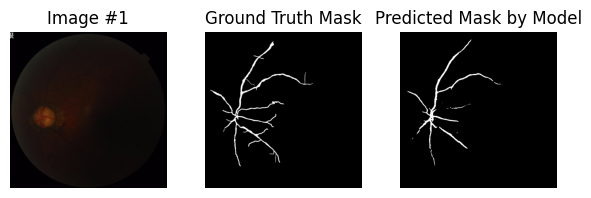

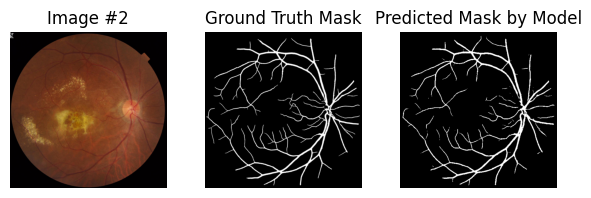

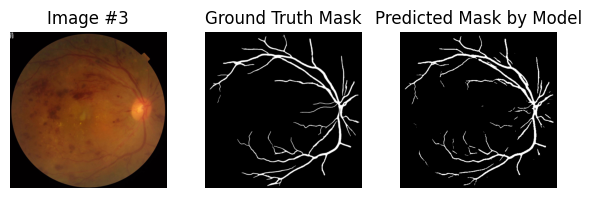

In [ ]:
train_losses, train_dice_scores, val_losses, val_dice_scores = train_one_epoch(model1, train_loader, val_loader, optimizer1, EPOCHS=20, device=device)

print("\n--- Starting Evaluation on Validation Set ---")
val_metrics = evaluate_model_pytorch(model1, X_val, y_val)

print("\n--- Final Validation Metrics (averaged) ---")
for k, v in val_metrics.items():
    print(f"{k.capitalize()}: {v:.4f}")

print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model1, X_val, y_val, num_samples=3)

Evaluating: 100%|██████████| 54/54 [00:30<00:00,  1.79it/s]



--- Final Metrics on the Test Set (averaged) ---
Dice: 0.6411
Iou: 0.4729
Accuracy: 0.9586
Sensitivity: 0.9321
Specificity: 0.9595
Auc: 0.9879

--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


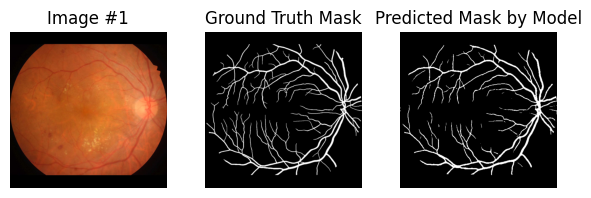

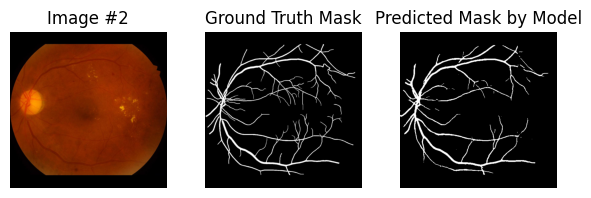

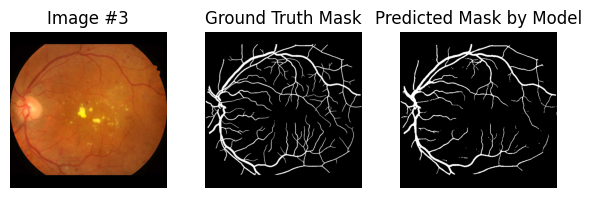

In [ ]:
# Evaluate
test_metrics = evaluate_model_pytorch(model1, test_images, test_masks)

# Display results
print("\n--- Final Metrics on the Test Set (averaged) ---")
for metric, value in test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model1, test_images, test_masks, num_samples=3)

### Model-3

In [ ]:
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, filters=[64, 128, 256, 512]):
        super(UNetPlusPlus, self).__init__()

        # Encoder
        self.conv0_0 = ConvBlock(in_channels, filters[0])
        self.conv1_0 = ConvBlock(filters[0], filters[1])
        self.conv2_0 = ConvBlock(filters[1], filters[2])
        self.conv3_0 = ConvBlock(filters[2], filters[3])

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Decoder with nested structure
        self.up1_0 = nn.ConvTranspose2d(filters[1], filters[0], 2, stride=2)
        self.conv0_1 = ConvBlock(filters[0]*2, filters[0])

        self.up2_0 = nn.ConvTranspose2d(filters[2], filters[1], 2, stride=2)
        self.conv1_1 = ConvBlock(filters[1]*2, filters[1])
        self.up1_1 = nn.ConvTranspose2d(filters[1], filters[0], 2, stride=2)
        self.conv0_2 = ConvBlock(filters[0]*3, filters[0])

        self.up3_0 = nn.ConvTranspose2d(filters[3], filters[2], 2, stride=2)
        self.conv2_1 = ConvBlock(filters[2]*2, filters[2])
        self.up2_1 = nn.ConvTranspose2d(filters[2], filters[1], 2, stride=2)
        self.conv1_2 = ConvBlock(filters[1]*3, filters[1])
        self.up1_2 = nn.ConvTranspose2d(filters[1], filters[0], 2, stride=2)
        self.conv0_3 = ConvBlock(filters[0]*4, filters[0])

        # Final output layer
        self.final = nn.Conv2d(filters[0], out_channels, kernel_size=1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up1_0(x1_0)], dim=1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up2_0(x2_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up1_1(x1_1)], dim=1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up3_0(x3_0)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up2_1(x2_1)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up1_2(x1_2)], dim=1))

        output = self.final(x0_3)
        return output

model2 = UNetPlusPlus(in_channels=3, out_channels=1)
model2 = model2.to(device)

In [ ]:
optimizer2 = optim.AdamW(model2.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', patience=5, factor=0.1
)

100%|██████████| 209/209 [00:03<00:00, 55.47it/s]


Epoch [1/5] - Train Loss: 0.6905 - Train Dice: 0.5218 - Val Loss: 0.3599 - Val Dice: 0.7443


100%|██████████| 209/209 [00:03<00:00, 55.34it/s]


Epoch [2/5] - Train Loss: 0.3145 - Train Dice: 0.7846 - Val Loss: 0.2888 - Val Dice: 0.8001


100%|██████████| 209/209 [00:03<00:00, 56.29it/s]


...

Epoch [5/5] - Train Loss: 0.2578 - Train Dice: 0.8272 - Val Loss: 0.2628 - Val Dice: 0.8208

--- Starting Evaluation on Validation Set ---


Evaluating:  76%|███████▌  | 53/70 [00:12<00:03,  4.27it/s]

Image 52 ground truth lacks both classes. Skipping.


Evaluating: 100%|██████████| 70/70 [00:15<00:00,  4.45it/s]



--- Final Validation Metrics (averaged) ---
Dice: 0.6998
Iou: 0.5465
Accuracy: 0.9664
Sensitivity: 0.9531
Specificity: 0.9666
Auc: 0.9926

--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


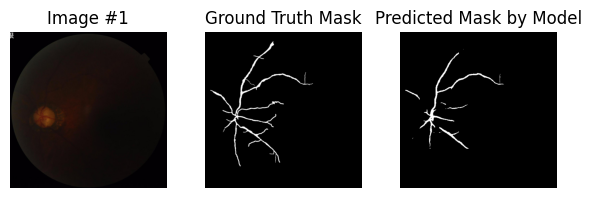

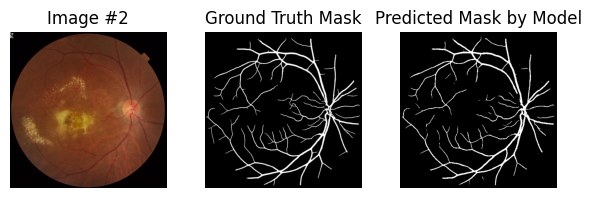

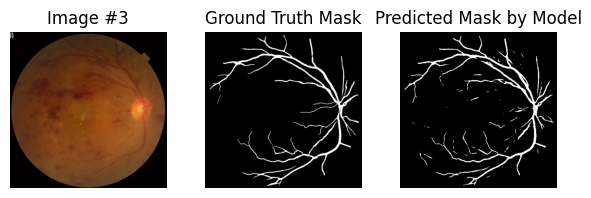

In [ ]:
train_losses, train_dice_scores, val_losses, val_dice_scores = train_one_epoch(model2, train_loader, val_loader, optimizer2, EPOCHS=20, device=device)

print("\n--- Starting Evaluation on Validation Set ---")
val_metrics = evaluate_model_pytorch(model2, X_val, y_val)

print("\n--- Final Validation Metrics (averaged) ---")
for k, v in val_metrics.items():
    print(f"{k.capitalize()}: {v:.4f}")

print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model2, X_val, y_val, num_samples=3)

Evaluating: 100%|██████████| 54/54 [00:11<00:00,  4.81it/s]



--- Final Metrics on the Test Set (averaged) ---
Dice: 0.6463
Iou: 0.4786
Accuracy: 0.9597
Sensitivity: 0.9267
Specificity: 0.9609
Auc: 0.9880

--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


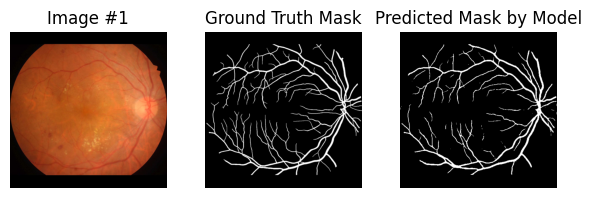

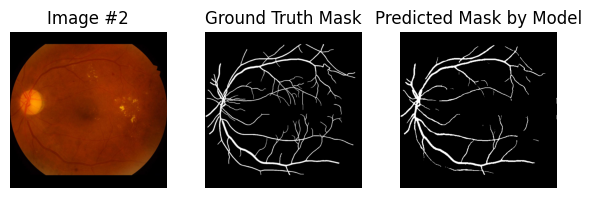

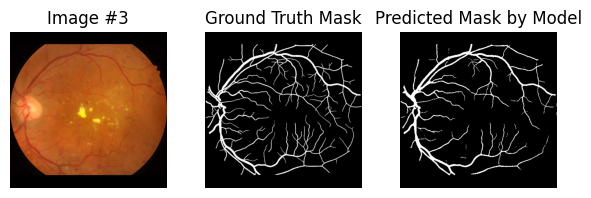

In [ ]:
# Evaluate
test_metrics = evaluate_model_pytorch(model2, test_images, test_masks)

# Display results
print("\n--- Final Metrics on the Test Set (averaged) ---")
for metric, value in test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model2, test_images, test_masks, num_samples=3)